# MDD Cluster Boxplot – Mean Contrast per Condition
Mean contrast estimate within the MDD EOI cluster, across all 4 conditions (MDD subjects only).

Data source: `results/cluster_betas_MDD.csv` (extracted via `extract_cluster_betas_MDD.m`)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

csv_path = 'results/cluster_betas_MDD.csv'
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} rows, {df['subject'].nunique()} subjects")
df.head(8)

Loaded 212 rows, 53 subjects


,subject,condition,mean_contrast
0,sub-007,happy_primer_happy_target,0.615173
1,sub-007,happy_primer_sad_target,-0.355121
2,sub-007,sad_primer_sad_target,0.460958
3,sub-007,sad_primer_happy_target,0.306665
4,sub-008,happy_primer_happy_target,0.187577
5,sub-008,happy_primer_sad_target,0.399466
6,sub-008,sad_primer_sad_target,0.527563
7,sub-008,sad_primer_happy_target,-0.371241


In [7]:
# Condition order & readable labels
cond_order  = ['happy_primer_happy_target', 'happy_primer_sad_target',
               'sad_primer_sad_target',     'sad_primer_happy_target']
cond_labels = ['Happy–Happy', 'Happy–Sad', 'Sad–Sad', 'Sad–Happy']
color       = '#CC79A7'   # MDD pink (colorblind-friendly)

df['condition_label'] = df['condition'].map(dict(zip(cond_order, cond_labels)))
df['condition_label'] = pd.Categorical(df['condition_label'],
                                        categories=cond_labels, ordered=True)
print("n subjects:", df['subject'].nunique())
print("n per condition:", df.groupby('condition_label').size().to_dict())

n subjects: 53
n per condition: {'Happy–Happy': 53, 'Happy–Sad': 53, 'Sad–Sad': 53, 'Sad–Happy': 53}


/var/folders/9b/chqdnw6s3n53n2705_dlsllc0000gn/T/ipykernel_8657/1564461446.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("n per condition:", df.groupby('condition_label').size().to_dict())


## Boxplot per condition (MDD only)

Each dot = one MDD subject. Boxplot shows median, IQR, and whiskers (1.5×IQR).

Significance brackets show **paired t-tests** between conditions (same subjects → within-subject comparison), **Bonferroni-corrected** for 6 pairwise comparisons (α = 0.05/6 ≈ 0.0083). Only significant pairs are shown.

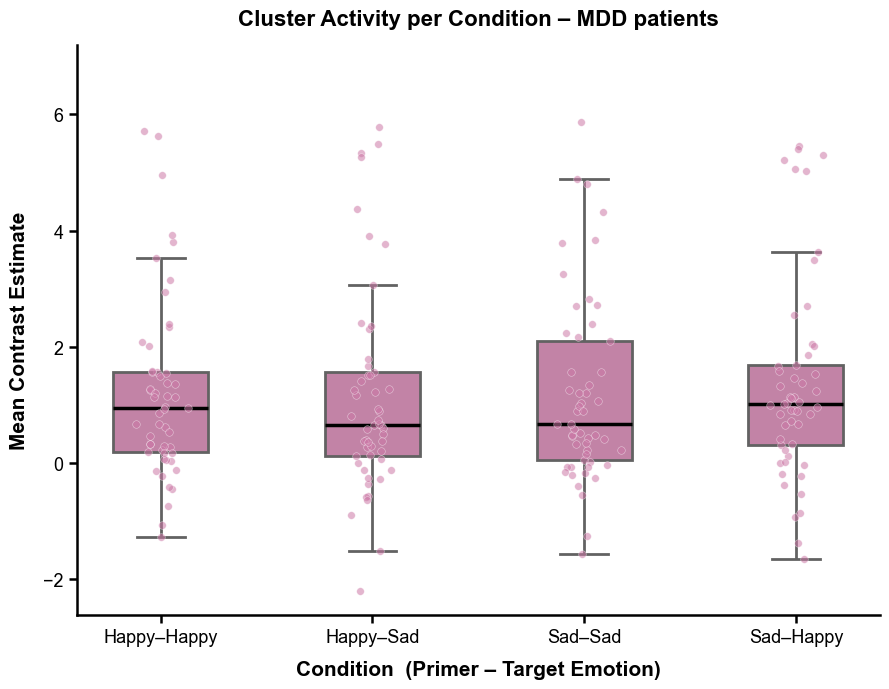

In [12]:
import matplotlib.patches as mpatches
from itertools import combinations

# ── GraphPad Prism style ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'Arial',
    'axes.linewidth'   : 1.8,
    'xtick.major.width': 1.8,
    'ytick.major.width': 1.8,
    'xtick.major.size' : 6,
    'ytick.major.size' : 6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(9, 7))

# Boxplot
sns.boxplot(
    data         = df,
    x            = 'condition_label',
    y            = 'mean_contrast',
    color        = color,
    width        = 0.45,
    linewidth    = 2.0,
    fliersize    = 0,
    boxprops     = dict(linewidth=2.0),
    whiskerprops = dict(linewidth=2.0),
    medianprops  = dict(linewidth=2.5, color='black'),
    capprops     = dict(linewidth=2.0),
    ax           = ax
)

# Jittered individual data points (larger, more opaque)
rng = np.random.default_rng(42)
for i, cond in enumerate(cond_labels):
    vals     = df[df['condition_label'] == cond]['mean_contrast']
    x_jitter = rng.normal(i, 0.06, size=len(vals))
    ax.scatter(x_jitter, vals, color=color, alpha=0.55, s=30, zorder=3,
               edgecolors='white', linewidths=0.4)

# Paired t-tests between all condition pairs – Bonferroni-corrected (6 comparisons)
pairs     = list(combinations(range(len(cond_labels)), 2))
n_tests   = len(pairs)   # 6
alpha_bon = 0.05 / n_tests   # 0.0083

y_max    = df['mean_contrast'].max()
y_min    = df['mean_contrast'].min()
y_range  = y_max - y_min
bracket_step = y_range * 0.13

sig_pairs = []
for i1, i2 in pairs:
    cond1 = cond_labels[i1]
    cond2 = cond_labels[i2]
    vals1 = df[df['condition_label'] == cond1].sort_values('subject')['mean_contrast'].values
    vals2 = df[df['condition_label'] == cond2].sort_values('subject')['mean_contrast'].values
    _, p  = stats.ttest_rel(vals1, vals2)

    if p < 0.001 / n_tests:
        sig = '***'
    elif p < 0.01 / n_tests:
        sig = '**'
    elif p < alpha_bon:
        sig = '*'
    else:
        sig = None

    if sig:
        sig_pairs.append((i1, i2, sig, p))

# Draw brackets only for significant pairs, stacked by span width
sig_pairs_sorted = sorted(sig_pairs, key=lambda x: x[1] - x[0])
for lvl, (i1, i2, sig, p) in enumerate(sig_pairs_sorted):
    y_br = y_max + y_range * 0.1 + lvl * bracket_step
    ax.plot([i1, i1, i2, i2],
            [y_br - bracket_step*0.2, y_br, y_br, y_br - bracket_step*0.2],
            lw=1.8, color='black')
    ax.text((i1 + i2) / 2, y_br + bracket_step * 0.05, sig,
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Adjust y-axis to fit brackets
n_brackets = len(sig_pairs_sorted)
ax.set_ylim(y_min - y_range * 0.05,
            y_max + y_range * 0.1 + (n_brackets + 0.5) * bracket_step)

# Labels & styling
ax.set_xlabel('Condition  (Primer \u2013 Target Emotion)', fontsize=15, fontweight='bold', labelpad=10)
ax.set_ylabel('Mean Contrast Estimate', fontsize=15, fontweight='bold', labelpad=10)
ax.set_title('Cluster Activity per Condition \u2013 MDD patients', fontsize=16,
             fontweight='bold', pad=14)
ax.set_xticks(range(len(cond_labels)))
ax.set_xticklabels(cond_labels, fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
#ax.text(0.01, 0.01, f'Paired t-tests, Bonferroni-corrected (\u03b1\u202f=\u202f{alpha_bon:.4f})',
#        transform=ax.transAxes, fontsize=9, color='gray', va='bottom')

sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [9]:
sig_pairs

[]

## Save figure

In [13]:
fig.savefig('results/cluster_boxplot_MDD.svg', dpi=300, bbox_inches='tight')
fig.savefig('results/cluster_boxplot_MDD.png', dpi=300, bbox_inches='tight')
print('Saved to results/')

Saved to results/
